Stage 1 — NTU Full (120 классов) → обучаем backbone

Stage 2 — NTU-flu / BIISK (13/8 классов) → тонкая адаптация

Stage 3 — бинарная или weighted классификация с attention, заточенная под cough

In [2]:
import os
import torch
def setup_device(gpu_id: int = 0) -> torch.device:
    os.environ.pop("CUDA_VISIBLE_DEVICES", None)
    if torch.cuda.is_available():
        device = torch.device(f"cuda:{gpu_id}")
        torch.backends.cudnn.benchmark = True
        props = torch.cuda.get_device_properties(gpu_id)
        print(f"{'='*60}")
        print(f"🚀 GPU: {torch.cuda.get_device_name(gpu_id)}")
        print(f"   VRAM: {props.total_memory / 1e9:.1f} GB")
        print(f"   CUDA: {torch.version.cuda} | Torch: {torch.__version__}")
        print(f"{'='*60}\n")
    else:
        device = torch.device("cpu")
        print(f"{'='*60}")
        print("⚠️  GPU недоступен — используем CPU")
        print(f"{'='*60}\n")
    return device


In [21]:
# ── Блок 0: Окружение ────────────────────────────────────────────────────
import sys, os
# sys.path.append(r"c:\diplommaga\dataset\handlerntu\fine_tuning")
# os.chdir(r"c:\diplommaga\dataset\handlerntu\fine_tuning")

import torch
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from omegaconf import OmegaConf

print(f"PyTorch  : {torch.__version__}")
print(f"Lightning: {pl.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"CWD      : {os.getcwd()}")

PyTorch  : 2.7.1+cu118
Lightning: 2.6.1
CUDA     : True | NVIDIA GeForce RTX 3050 4GB Laptop GPU
CWD      : c:\diplommaga\dataset\handlerntu\fine_tuning


In [22]:
# ── Блок 2: Утилиты ──────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def run_eval(model, loader, class_names, device="cuda", smooth=False):
    """Полная оценка модели: confusion matrix + classification report."""
    from scipy.signal import savgol_filter
    model.eval().to(device)
    all_y, all_yhat = [], []
    with torch.no_grad():
        for xb, yb in loader:
            if smooth:
                arr = savgol_filter(xb.numpy(), window_length=7, polyorder=2, axis=2)
                xb  = torch.tensor(arr, dtype=torch.float32)
            logits = model(xb.to(device))
            preds  = logits.argmax(1).cpu().numpy()
            all_y.append(yb.numpy())
            all_yhat.append(preds)
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_yhat)
    print(classification_report(y_true, y_pred, target_names=class_names))
    return y_true, y_pred

def plot_cm(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(class_names)), max(5, len(class_names)-1)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

def save_backbone(trainer, out_path):
    """Сохраняет только backbone+data_bn из лучшего чекпоинта Lightning."""
    ckpt = torch.load(trainer.checkpoint_callback.best_model_path, map_location="cpu")
    sd   = {k: v for k, v in ckpt["state_dict"].items()
            if not k.startswith("head.")}
    torch.save(sd, out_path)
    print(f"✅ Backbone сохранён → {out_path}")
    return out_path

def make_trainer(cfg, name, extra_callbacks=None):
    """Создаёт стандартный Trainer с чекпоинтами и ранней остановкой."""
    callbacks = [
        ModelCheckpoint(
            dirpath   = cfg.train.ckpt_dir,
            filename  = f"{name}" + "-{epoch:02d}-{val/f1:.3f}",
            monitor   = "val/f1",
            mode      = "max",
            save_top_k= 3,
            save_last = True,
        ),
        EarlyStopping(monitor="val/f1", mode="max", patience=12, verbose=True),
    ]
    if extra_callbacks:
        callbacks += extra_callbacks
    return pl.Trainer(
        max_epochs       = cfg.train.max_epochs,
        logger           = TensorBoardLogger(cfg.train.log_dir, name=name),
        callbacks        = callbacks,
        default_root_dir = cfg.train.ckpt_dir,
        accelerator      = "gpu",
        devices          = 1,
        log_every_n_steps= 10,
    )

print("✅ Утилиты готовы")

✅ Утилиты готовы


# STGCNStage2

In [7]:
class Graph:
    COCO_EDGES = [
        (0,1),(0,2),(1,3),(2,4),           # голова
        (5,6),(5,7),(7,9),(6,8),(8,10),    # руки
        (5,11),(6,12),(11,12),             # торс
        (11,13),(13,15),(12,14),(14,16),   # ноги
    ]

    def __init__(self, num_joints: int = 17):
        self.num_joints = num_joints

    def get_adjacency(self) -> torch.Tensor:
        V = self.num_joints
        A = torch.zeros(V, V)

        for i, j in self.COCO_EDGES:
            A[i, j] = A[j, i] = 1.0

        # self-loops: каждый сустав соединён сам с собой
        A += torch.eye(V)

        # нормализация D^-0.5 * A * D^-0.5
        D = A.sum(dim=1).pow(-0.5)
        D[D == float("inf")] = 0  # защита от деления на 0
        A = D.unsqueeze(1) * A * D.unsqueeze(0)

        return A  # (V, V)


In [8]:
import torch
import torch.nn as nn

In [9]:
class STGCNBlock(nn.Module):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        A: torch.Tensor,        # adjacency matrix (V, V)
        temporal_kernel: int = 9,
        stride: int = 1,
        dropout: float = 0.0,
    ):
        super().__init__()

        # регистрируем A как buffer — он сохраняется в checkpoint,
        # переносится на GPU вместе с моделью, но не обучается
        self.register_buffer("A", A)

        # ── Spatial: свёртка 1x1 по каналам + умножение на A ────────
        # Conv2d(in, out, 1) применяется к каждому (frame, joint) независимо
        self.gcn = nn.Conv2d(in_channels, out_channels, kernel_size=1)

        # ── Temporal: свёртка по оси времени ────────────────────────
        pad = (temporal_kernel - 1) // 2   # same padding — выход той же длины
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=(temporal_kernel, 1),
                padding=(pad, 0),
                stride=(stride, 1),
            ),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(dropout),
        )

        # ── Skip connection ──────────────────────────────────────────
        # если размерности не совпадают — проецируем через Conv 1x1
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1,
                    stride=(stride, 1),
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T, V)

        # spatial: x → умножаем признаки каждого сустава
        # на взвешенную сумму признаков соседей
        x_sp = torch.einsum("nctv,vw->nctw", x, self.A)  # (B, C, T, V)
        x_sp = self.gcn(x_sp)                             # (B, out, T, V)

        # temporal
        out = self.tcn(x_sp) + self.skip(x)
        return self.relu(out)


In [5]:
# stgcn_model.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torchmetrics import Accuracy, F1Score
from omegaconf import OmegaConf


# ─────────────────────────────────────────────────────────────────────────
# Spatial Attention (добавляется после блоков 4–6)
# ─────────────────────────────────────────────────────────────────────────
class SpatialAttention(nn.Module):
    """
    Каждый сустав взвешивается по своим собственным C=256 признакам.
    Conv1d(256, 1, k=1): вес сустава V_i зависит только от признаков V_i.
    Параметров: 257 вместо 74 000.
    nn.init.zeros_ → softmax(0) = 1/17 → гарантированный uniform старт.
    """
    def __init__(self, in_channels: int, num_joints: int):
        super().__init__()
        self.gap     = nn.AdaptiveAvgPool2d((1, num_joints))  # усредняем время
        self.conv    = nn.Conv1d(in_channels, 1, kernel_size=1, bias=True)
        self.softmax = nn.Softmax(dim=-1)

        nn.init.zeros_(self.conv.weight)  # softmax(zeros) = 1/num_joints
        nn.init.zeros_(self.conv.bias)

    def forward(self, x):
        # x: (B, C, T, V)
        B, C, T, V = x.shape
        gap = self.gap(x).squeeze(2)      # (B, C, V)
        w   = self.conv(gap).squeeze(1)   # (B, V)
        w   = self.softmax(w)             # (B, V)  сумма по V = 1
        return x * w.view(B, 1, 1, V)    # broadcast по C и T


# ─────────────────────────────────────────────────────────────────────────
# Temporal Attention
# ─────────────────────────────────────────────────────────────────────────
class TemporalAttention(nn.Module):
    """
    Каждый временной шаг взвешивается по своим C=256 признакам.
    sigmoid(0) = 0.5 → нейтральный старт (ничего не подавляет, ничего не усиливает).
    """
    def __init__(self, in_channels: int):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, 1, kernel_size=1, bias=True)

        nn.init.zeros_(self.conv.weight)  # sigmoid(0) = 0.5
        nn.init.zeros_(self.conv.bias)

    def forward(self, x):
        # x: (B, C, T, V)
        B, C, T, V = x.shape
        gap = x.mean(dim=-1)                    # (B, C, T) — усредняем по суставам
        w   = torch.sigmoid(self.conv(gap))     # (B, 1, T)
        return x * w.unsqueeze(-1)              # broadcast по V


# ─────────────────────────────────────────────────────────────────────────
# Head с проекционным слоем 256
# ─────────────────────────────────────────────────────────────────────────
class STGCNHead(nn.Module):
    """
    Голова с дополнительным projection layer 256.

    backbone output (B, hdim, T', V)
      → SpatialAttention (опционально)
      → TemporalAttention (опционально)
      → AdaptiveAvgPool → Flatten
      → Linear(hdim, 256) → ReLU → Dropout
      → Linear(256, num_classes)
    """
    def __init__(
        self,
        in_dim:      int,
        num_classes: int,
        dropout:     float = 0.3,
        num_joints:  int   = 17,
        use_spatial_attn:  bool = False,
        use_temporal_attn: bool = False,
    ):
        super().__init__()
        self.spatial_attn  = SpatialAttention(in_dim, num_joints) \
                             if use_spatial_attn  else nn.Identity()
        self.temporal_attn = TemporalAttention(in_dim) \
                             if use_temporal_attn else nn.Identity()

        self.pool    = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.proj    = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.spatial_attn(x)
        x = self.temporal_attn(x)
        x = self.flatten(self.pool(x))   # (B, in_dim)
        feat = self.proj(x)              # (B, 256)
        return self.classifier(feat), feat   # возвращаем и logits, и embedding


# ─────────────────────────────────────────────────────────────────────────
# STGCNStage2  (универсальный для всех стадий)
# ─────────────────────────────────────────────────────────────────────────
class STGCNStage2(pl.LightningModule):
    """
    Универсальная модель для Stage 1 (NTU Full), Stage 2 (NTU-flu/BIISK),
    Stage 3 (cough-focused fine-tune).

    Стратегии заморозки:
      freeze_all   → только head
      freeze_early → блоки 0-4 заморожены, 5-6 + head обучаются
      full         → всё, backbone с малым lr

    Attention:
      cfg.model.use_spatial_attn  = True/False
      cfg.model.use_temporal_attn = True/False

    Взвешивание классов (Stage 3):
      cfg.train.class_weights = [w0, w1, ...] или [] (uniform)
    """

    def __init__(self, cfg):
        super().__init__()
        self.save_hyperparameters(OmegaConf.to_container(cfg, resolve=True))
        self.cfg = cfg

        nc   = cfg.model.num_classes
        drop = cfg.model.dropout
        hdim = cfg.model.hidden_dim

        A = Graph(num_joints=cfg.data.num_joints).get_adjacency()

        self.data_bn  = nn.BatchNorm1d(cfg.model.in_channels * cfg.data.num_joints)
        self.backbone = nn.ModuleList([
            STGCNBlock(cfg.model.in_channels, 64,   A, dropout=drop),
            STGCNBlock(64,   64,   A, dropout=drop),
            STGCNBlock(64,   64,   A, dropout=drop),
            STGCNBlock(64,   128,  A, dropout=drop, stride=2),
            STGCNBlock(128,  128,  A, dropout=drop),
            STGCNBlock(128,  hdim, A, dropout=drop, stride=2),
            STGCNBlock(hdim, hdim, A, dropout=drop),
        ])

        self.head = STGCNHead(
            in_dim     = hdim,
            num_classes= nc,
            dropout    = drop,
            num_joints = cfg.data.num_joints,
            use_spatial_attn  = cfg.model.get("use_spatial_attn",  False),
            use_temporal_attn = cfg.model.get("use_temporal_attn", False),
        )

        self._load_backbone(cfg.model.backbone_ckpt)
        self._apply_freeze_strategy(cfg.model.freeze_strategy)

        # ── class weights для focal / weighted CE (Stage 3) ──────────
        cw = cfg.train.get("class_weights", [])
        if cw:
            self.register_buffer(
                "class_weights",
                torch.tensor(cw, dtype=torch.float32)
            )
        else:
            self.class_weights = None

        for split in ("train", "val"):
            setattr(self, f"{split}_acc",
                    Accuracy(task="multiclass", num_classes=nc))
            setattr(self, f"{split}_f1",
                    F1Score(task="multiclass", num_classes=nc, average="macro"))

    # ── загрузка backbone ─────────────────────────────────────────────
    def _load_backbone(self, ckpt_path: str):
        if not ckpt_path:
            print("Backbone: init from scratch")
            return
        state = torch.load(ckpt_path, map_location="cpu")
        if "state_dict" in state:
            sd = {k: v for k, v in state["state_dict"].items()
                  if not k.startswith("head.")}
        else:
            sd = {k: v for k, v in state.items()
                  if not k.startswith("head.")}
        missing, unexpected = self.load_state_dict(sd, strict=False)
        head_keys   = [k for k in missing if k.startswith("head")]
        other_miss  = [k for k in missing if not k.startswith("head")]
        print(f"✅ Backbone загружен из {ckpt_path}")
        print(f"   head (переинициализирован): {len(head_keys)}")
        if other_miss:
            print(f"   ⚠ Не загружено: {other_miss}")

    # ── стратегия заморозки ───────────────────────────────────────────
    def _apply_freeze_strategy(self, strategy: str):
        if strategy == "freeze_all":
            for p in self.data_bn.parameters(): p.requires_grad = False
            for layer in self.backbone:
                for p in layer.parameters(): p.requires_grad = False
            print("❄️  freeze_all: только head")
        elif strategy == "freeze_early":
            for p in self.data_bn.parameters(): p.requires_grad = False
            for i, layer in enumerate(self.backbone):
                for p in layer.parameters(): p.requires_grad = i >= 5
            print("❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются")
        elif strategy == "full":
            print("🔓 full: весь backbone обучается")
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"   Параметров: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    # ── forward ───────────────────────────────────────────────────────
    def forward(self, x):
        B, C, T, V = x.shape
        x = x.permute(0, 1, 3, 2).contiguous().view(B, C * V, T)
        x = self.data_bn(x)
        x = x.view(B, C, V, T).permute(0, 1, 3, 2)
        for layer in self.backbone:
            x = layer(x)
        logits, feat = self.head(x)
        return logits     # feat доступен через self.head.forward() напрямую если нужен

    def _shared_step(self, batch, split):
        x, y   = batch
        logits = self(x)
        loss   = F.cross_entropy(logits, y, weight=self.class_weights)
        preds  = logits.argmax(dim=1)
        getattr(self, f"{split}_acc")(preds, y)
        getattr(self, f"{split}_f1")(preds, y)
        self.log(f"{split}/loss", loss, prog_bar=True, on_epoch=True)
        self.log(f"{split}/acc",  getattr(self, f"{split}_acc"), prog_bar=True, on_epoch=True)
        self.log(f"{split}/f1",   getattr(self, f"{split}_f1"),  prog_bar=True, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def configure_optimizers(self):
        strategy = self.cfg.model.freeze_strategy
        if strategy == "full":
            param_groups = [
                {"params": list(self.data_bn.parameters()) +
                           list(self.backbone.parameters()),
                 "lr": self.cfg.train.lr_backbone},
                {"params": list(self.head.parameters()),
                 "lr": self.cfg.train.lr},
            ]
            opt = torch.optim.AdamW(param_groups,
                                    weight_decay=self.cfg.train.weight_decay)
        else:
            opt = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, self.parameters()),
                lr=self.cfg.train.lr,
                weight_decay=self.cfg.train.weight_decay,
            )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=self.cfg.train.max_epochs, eta_min=1e-6
        )
        return {"optimizer": opt, "lr_scheduler": scheduler}

In [10]:
# Запусти перед обучением — убедись что всё собрано правильно

model3 = STGCNStage2(cfg3)

# 1. Форма выхода
dummy = torch.randn(4, 2, 64, 17)
with torch.no_grad():
    out = model3(dummy)
print(f"Output shape: {out.shape}")   # ожидаем (4, 8)

# 2. Заморозка — что обучается
trainable = [(n, p.shape) for n, p in model3.named_parameters() if p.requires_grad]
frozen    = [(n, p.shape) for n, p in model3.named_parameters() if not p.requires_grad]
print(f"\nОбучаемых параметров: {len(trainable)}")
print(f"Замороженных:         {len(frozen)}")
# При freeze_early: backbone.0–4 заморожены, backbone.5–6 + head обучаются

# 3. Attention присутствует
print(f"\nSpatialAttention:  {type(model3.head.spatial_attn)}")
print(f"TemporalAttention: {type(model3.head.temporal_attn)}")
# Не должно быть nn.Identity()

# 4. Head структура
print(f"\nHead:\n{model3.head}")

NameError: name 'cfg3' is not defined

# Импорты


In [6]:
# ── Блок 1: Импорты проекта ──────────────────────────────────────────────
from augmentation       import VirtualCamera, PRESET_CAMERAS, apply_transform_to_skeleton
# from stgcn_model        import STGCNStage2          # модель из предыдущего сообщения
# from graph              import Graph
# from stgcn_block        import STGCNBlock

# Конфиги
from ntu_full_config    import cfg_ntu_full, NTU_ACTION_NAMES, action_id_to_name
from ntu_flu_config     import cfg_ntu, NTU_FLU_CLASSES
import numpy as np
# cfg_stage3 определяем прямо в ноутбуке ниже

# DataModules
from ntu_full_dataset   import NTUFullDataModule
from ntu_flu_dataset    import NTUFluDataModule     # или BiiskDataModule

print("✅ Все импорты успешны")

✅ Все импорты успешны


# STAGE 1: Конфиг NTU Full

In [17]:
# ── Блок 3: Stage 1 — конфиг ────────────────────────────────────────────
# Обучаем на ВСЁМ NTU RGB+D (120 классов) без меток на Stage 2

# Если хочешь только flu-релевантные классы для быстрой проверки:
# cfg_ntu_full.data.action_ids = [10,28,34,35,37,41,48,76,77,78,103]

cfg_ntu_full.data.action_ids  = []       # [] = все классы
cfg_ntu_full.model.backbone_ckpt   = ""  # с нуля
cfg_ntu_full.model.freeze_strategy = "full"
cfg_ntu_full.model.use_spatial_attn  = False
cfg_ntu_full.model.use_temporal_attn = False

print(OmegaConf.to_yaml(cfg_ntu_full))

data:
  skeleton_dirs:
  - ../data_ntu_npz
  action_ids: []
  num_frames: 64
  num_joints: 17
  conf_thresh: 0.0
  projection_view: front
augmentation:
  enabled: true
  aug3d_enabled: true
  cctv_presets_3d:
  - cctv_front_15
  - cctv_front_30
  - cctv_side_15
  - cctv_side_30
  - mirror_horizontal
  cctv_prob: 0.5
  rot3d_y_prob: 0.4
  rot3d_y_range: 30.0
  aug2d_enabled: true
  mirror_prob: 0.5
  rotate2d_prob: 0.4
  rotate2d_range: 15.0
  noise_std: 0.02
  time_crop_prob: 0.4
  time_crop_frac: 0.15
cctv_benchmark:
  enabled: true
  projection_view: front
  presets:
  - cctv_front_15
  - cctv_front_30
  - cctv_side_30
  - cctv_back
model:
  in_channels: 2
  num_classes: -1
  dropout: 0.3
  hidden_dim: 256
  backbone_ckpt: ''
  freeze_strategy: full
  use_spatial_attn: false
  use_temporal_attn: false
train:
  batch_size: 32
  lr: 0.0003
  lr_backbone: 0.0003
  weight_decay: 0.0001
  max_epochs: 60
  val_split: 0.1
  num_workers: 4
  seed: 42
  ckpt_dir: checkpoints/ntu_full
  log_di

## STAGE 1: DataModule + проверка данных

In [18]:
# ── Блок 4: Stage 1 — данные ─────────────────────────────────────────────
dm1 = NTUFullDataModule(cfg_ntu_full)
dm1.setup("fit")

# Быстрая проверка батча
xb, yb = next(iter(dm1.train_dataloader()))
print(f"xb shape : {xb.shape}   # ожидаем (B, 2, 64, 17)")
print(f"yb shape : {yb.shape}")
print(f"Классов  : {cfg_ntu_full.model.num_classes}")
print(f"Примеры классов: {dm1.classes[:10]} ...")

NTUFullDataset [view=front]: 56880 сэмплов | 60 классов | dirs=1
num_classes установлен автоматически: 60
NTUFullDataset [view=front]: 56880 сэмплов | 60 классов | dirs=1
NTUFullDataset [view=front]: 56880 сэмплов | 60 классов | dirs=1
NTUFullDataset [view=front]: 56880 сэмплов | 60 классов | dirs=1
NTUFullDataset [view=front]: 56880 сэмплов | 60 классов | dirs=1
NTUFullDataset [view=front]: 56880 сэмплов | 60 классов | dirs=1
Train: 51192 | Val: 5688
Benchmark: ['cctv_front_15', 'cctv_front_30', 'cctv_side_30', 'cctv_back']
xb shape : torch.Size([32, 2, 64, 17])   # ожидаем (B, 2, 64, 17)
yb shape : torch.Size([32])
Классов  : 60
Примеры классов: ['drink_water', 'eat_meal', 'brush_teeth', 'brush_hair', 'drop', 'pickup', 'throw', 'sitting_down', 'standing_up', 'clapping'] ...


## STAGE 1: Обучение

In [19]:
# ── Блок 5: Stage 1 — обучение ───────────────────────────────────────────
model1   = STGCNStage2(cfg_ntu_full)
trainer1 = make_trainer(cfg_ntu_full, name="stage1_ntu_full")
trainer1.fit(model1, datamodule=dm1)

NameError: name 'Graph' is not defined

In [ ]:
BACKBONE_S1 = "checkpoints/ntu_full/backbone_ntu120.pt"
os.makedirs("checkpoints/ntu_full", exist_ok=True)
save_backbone(trainer1, BACKBONE_S1)

NameError: name 'os' is not defined

In [15]:
BACKBONE_S1 = "checkpoints/ntu_full/backbone_ntu120.pt"

## Быстрая оценка

In [11]:
# ── Блок 7: Stage 1 — оценка (исправлено) ────────────────────────────────
y_true1, y_pred1 = run_eval(model1, dm1.val_dataloader(), dm1.classes)

# Топ-20 классов по количеству примеров в val
top_ids = np.argsort(np.bincount(y_true1))[-20:]

# Оставляем только примеры где true-класс входит в топ-20
mask = np.isin(y_true1, top_ids)
yt   = y_true1[mask]
yp   = y_pred1[mask]

# ← ключевой фикс: remapping индексов 0..119 → 0..19
id2new = {old: new for new, old in enumerate(top_ids)}
yt_remap = np.array([id2new[i] for i in yt])
yp_remap = np.array([id2new.get(i, -1) for i in yp])   # -1 если pred не в топ-20

# убираем строки где pred вышел за топ-20 (опционально)
valid    = yp_remap >= 0
yt_remap = yt_remap[valid]
yp_remap = yp_remap[valid]

top_names = [dm1.classes[i] for i in top_ids]
plot_cm(yt_remap, yp_remap, top_names, title="Stage 1 — Top-20 классов")

NameError: name 'run_eval' is not defined

# STAGE 2: Конфиг NTU-flu или BIISK

In [16]:
# ── Блок 8: Stage 2 — конфиг ─────────────────────────────────────────────
# Выбери что обучать:  "ntu_flu"  или  "biisk"
STAGE2_TARGET = "biisk"    # ← меняй здесь

if STAGE2_TARGET == "ntu_flu":
    cfg2 = cfg_ntu.copy()
    cfg2.model.backbone_ckpt   = BACKBONE_S1
    cfg2.model.freeze_strategy = "freeze_early"
    cfg2.model.use_spatial_attn  = False
    cfg2.model.use_temporal_attn = False
    CLASSES_S2 = NTU_FLU_CLASSES

else:  # biisk
    from omegaconf import OmegaConf
    BIISK_CLASSES = ["cough","call","drink","scratch","sneeze","stretch","wave","wipe"]
    cfg2 = OmegaConf.create({
            "data": {
            "skeleton_root": r"c:\diplommaga\dataset\handlerntu\fine_tuning\data_stage2\biisk_skeletons",
            "classes":       ["cough","call","drink","scratch","sneeze","stretch","wave","wipe"],
            "num_frames":    64,
            "num_joints":    17,
            "conf_thresh":   0.0,
            "cache":         True,   # ← весь датасет в RAM
        },
        "augmentation": {
            "enabled":         True,
            "mirror_prob":     0.5,
            "rotate2d_prob":   0.4,
            "rotate2d_range":  15.0,
            "noise_std":       0.02,
            "time_crop_prob":  0.4,
            "time_crop_frac":  0.15,
        },
        "cctv_benchmark": {
            "enabled": True,
            "projection_view": "front",
            "presets": ["cctv_front_15","cctv_front_30","cctv_side_30","cctv_back"],
        },
        "model": {
            "in_channels": 2, "num_classes": len(BIISK_CLASSES),
            "dropout": 0.3, "hidden_dim": 256,
            "backbone_ckpt":   BACKBONE_S1,
            "freeze_strategy": "freeze_early",
            "use_spatial_attn":  False,
            "use_temporal_attn": False,
        },
        "train": {
            "batch_size": 16, "lr": 3e-4, "lr_backbone": 3e-5,
            "weight_decay": 1e-4, "max_epochs": 40, "val_split": 0.2,
            "num_workers": 0, "seed": 42,
            "ckpt_dir": "checkpoints/stage2_biisk",
            "log_dir":  "logs/stage2_biisk",
            "class_weights": [],
        },
    })
    CLASSES_S2 = BIISK_CLASSES

print(f"Stage 2 target : {STAGE2_TARGET}")
print(f"Классов        : {len(CLASSES_S2)}")
print(f"Backbone       : {cfg2.model.backbone_ckpt}")

Stage 2 target : biisk
Классов        : 8
Backbone       : checkpoints/ntu_full/backbone_ntu120.pt


In [17]:
# ── Блок 9: Stage 2 — данные ─────────────────────────────────────────────
if STAGE2_TARGET == "ntu_flu":
    dm2 = NTUFluDataModule(cfg2)
else:
    from biisk_dataset import BiiskDataModule
    dm2 = BiiskDataModule(cfg2)   # тот же класс, другой cfg

dm2.setup("fit")

xb, yb = next(iter(dm2.train_dataloader()))
print(f"xb: {xb.shape} | yb: {yb.shape}")
print(f"Распределение классов (val): {np.bincount(np.array([y for _,y in dm2.val_ds]))}")

Предзагрузка 1920 файлов в RAM...
✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Предзагрузка 1920 файлов в RAM...
✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Train: 1536 | Val: 384
xb: torch.Size([16, 2, 64, 17]) | yb: torch.Size([16])
Распределение классов (val): [50 44 45 42 55 44 53 51]


In [3]:
# ── Блок 10: Stage 2 — обучение ──────────────────────────────────────────
model2   = STGCNStage2(cfg2)
trainer2 = make_trainer(cfg2, name=f"stage2_{STAGE2_TARGET}")
trainer2.fit(model2, datamodule=dm2)

NameError: name 'STGCNStage2' is not defined

In [23]:
model2   = STGCNStage2(cfg2)
trainer2 = make_trainer(cfg2, name=f"stage2_{STAGE2_TARGET}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Backbone загружен из checkpoints/ntu_full/backbone_ntu120.pt
   head (переинициализирован): 4
❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются
   Параметров: 1,382,408 / 1,832,460 (75.4%)


Лучший чекпоинт: C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val/f1=0.821.ckpt
✅ Backbone загружен из checkpoints/ntu_full/backbone_ntu120.pt
   head (переинициализирован): 4
❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются
   Параметров: 1,382,408 / 1,832,460 (75.4%)
              precision    recall  f1-score   support

       cough       0.72      0.84      0.78        50
        call       0.76      0.80      0.78        44
       drink       0.80      0.91      0.85        45
     scratch       0.69      0.57      0.62        42
      sneeze       0.85      0.84      0.84        55
     stretch       0.95      0.93      0.94        44
        wave       0.80      0.70      0.75        53
        wipe       1.00      1.00      1.00        51

    accuracy                           0.83       384
   macro avg       0.82      0.82      0.82       384
weighted avg       0.83      0.83      0.82       384



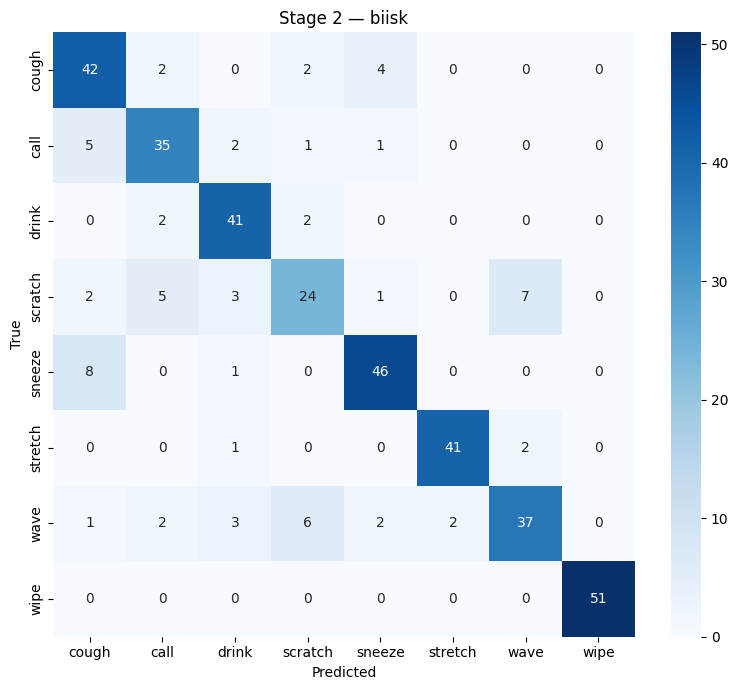

In [36]:
# ── Блок 11: Stage 2 — оценка ────────────────────────────────────────────
# Загружаем лучший чекпоинт
best2 = trainer2.checkpoint_callback.best_model_path
print(f"Лучший чекпоинт: {best2}")

model2_best = STGCNStage2.load_from_checkpoint(best2, cfg=cfg2)
y_true2, y_pred2 = run_eval(model2_best, dm2.val_dataloader(), CLASSES_S2)
plot_cm(y_true2, y_pred2, CLASSES_S2, title=f"Stage 2 — {STAGE2_TARGET}")

Лучший чекпоинт: C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val\f1=0.821.ckpt
✅ Backbone загружен из checkpoints/ntu_full/backbone_ntu120.pt
   head (переинициализирован): 4
❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются
   Параметров: 1,382,408 / 1,832,460 (75.4%)
              precision    recall  f1-score   support

       cough       0.72      0.84      0.78        50
        call       0.76      0.80      0.78        44
       drink       0.80      0.91      0.85        45
     scratch       0.69      0.57      0.62        42
      sneeze       0.85      0.84      0.84        55
     stretch       0.95      0.93      0.94        44
        wave       0.80      0.70      0.75        53
        wipe       1.00      1.00      1.00        51

    accuracy                           0.83       384
   macro avg       0.82      0.82      0.82       384
weighted avg       0.83      0.83      0.82       384



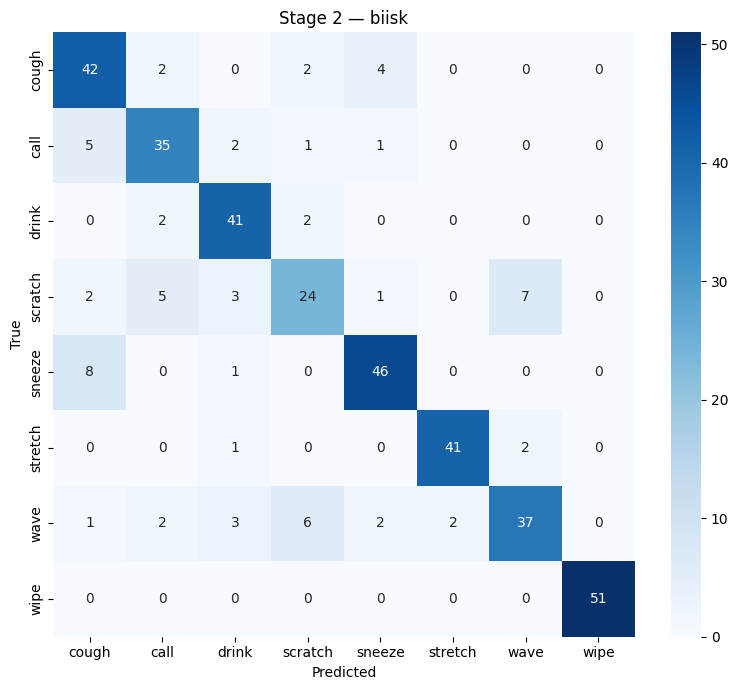

In [28]:
# ── Блок 11: Stage 2 — оценка ────────────────────────────────────────────
# Загружаем лучший чекпоинт
best2 = r'C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val\f1=0.821.ckpt'
print(f"Лучший чекпоинт: {best2}")

model2_best = STGCNStage2.load_from_checkpoint(best2, cfg=cfg2)
y_true2, y_pred2 = run_eval(model2_best, dm2.val_dataloader(), CLASSES_S2)
plot_cm(y_true2, y_pred2, CLASSES_S2, title=f"Stage 2 — {STAGE2_TARGET}")

In [29]:
from sklearn.metrics import precision_recall_fscore_support

# индексы классов cough и sneeze
RESP_CLASSES = {"cough", "sneeze"}
resp_idx = [i for i, c in enumerate(CLASSES_S2) if c in RESP_CLASSES]

# переводим многоклассовые метки в бинарные: resp vs background
y_resp_true = np.isin(y_true2, resp_idx).astype(int)
y_resp_pred = np.isin(y_pred2, resp_idx).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_resp_true, y_resp_pred, average="binary"
)

print(f"Stage 2 resp=(cough+sneeze) vs background")
print(f"precision = {prec:.3f}")
print(f"recall    = {rec:.3f}")
print(f"F1        = {f1:.3f}")

Stage 2 resp=(cough+sneeze) vs background
precision = 0.893
recall    = 0.952
F1        = 0.922


# Stage 3 — конфиг

In [13]:
# ── Блок 13: Stage 3 — конфиг ────────────────────────────────────────────
# BACKBONE_S2 = trainer2.checkpoint_callback.best_model_path
BACKBONE_S2 = "C:\\diplommaga\\dataset\\handlerntu\\fine_tuning\\checkpoints\\stage2_biisk\\stage2_biisk-epoch=38-val/f1=0.821.ckpt"

cfg3 = OmegaConf.create({
    "data": {
        "skeleton_root":   "data_stage2\\biisk_skeletons",
        "classes":         BIISK_CLASSES,
        "num_frames":      64,
        "num_joints":      17,
        "conf_thresh":     0.0,
        "projection_view": "front",
    },
    "augmentation": {
        "enabled": True,
        "aug3d_enabled": True,
        "cctv_presets_3d": ["cctv_front_15","cctv_front_30","cctv_side_15","cctv_side_30"],
        "cctv_prob": 0.6, "rot3d_y_prob": 0.4, "rot3d_y_range": 30.0,
        "aug2d_enabled": True, "mirror_prob": 0.5, "rotate2d_prob": 0.4,
        "rotate2d_range": 15.0, "noise_std": 0.02,
        "time_crop_prob": 0.4, "time_crop_frac": 0.15,
    },
    "cctv_benchmark": {
        "enabled": True, "projection_view": "front",
        "presets": ["cctv_front_15","cctv_front_30","cctv_side_30","cctv_back"],
    },
    "model": {
        "in_channels": 2, "num_classes": len(BIISK_CLASSES),
        "dropout": 0.4, "hidden_dim": 256,
        "backbone_ckpt":   BACKBONE_S2,
        "freeze_strategy": "freeze_early",
        # ← ATTENTION включается только здесь
        "use_spatial_attn":  True,
        "use_temporal_attn": True,
    },
    "train": {
        "batch_size": 16, "lr": 1e-4, "lr_backbone": 1e-5,
        "weight_decay": 1e-4, "max_epochs": 40, "val_split": 0.2,
        "num_workers": 0, "seed": 42,
        "ckpt_dir": "checkpoints/stage3_cough_attn",
        "log_dir":  "logs/stage3_cough_attn",
        # cough=3.0, sneeze=2.0, остальные=1.0
        # порядок: cough call drink scratch sneeze stretch wave wipe
        "class_weights": [3.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0],
    },
})

print("Stage 3 backbone:", BACKBONE_S2)
print("class_weights   :", cfg3.train.class_weights)

Stage 3 backbone: C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val/f1=0.821.ckpt
class_weights   : [3.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0]


In [14]:
BACKBONE_S2

'C:\\diplommaga\\dataset\\handlerntu\\fine_tuning\\checkpoints\\stage2_biisk\\stage2_biisk-epoch=38-val/f1=0.821.ckpt'

In [23]:
model3_check = STGCNStage2(cfg3)

# Attention должен давать uniform веса на случайном входе
dummy = torch.randn(4, 2, 64, 17)
with torch.no_grad():
    # Прогоняем через backbone вручную
    B, C, T, V = dummy.shape
    x = dummy.permute(0,1,3,2).contiguous().view(B, C*V, T)
    x = model3_check.data_bn(x)
    x = x.view(B, C, V, T).permute(0,1,3,2)
    for layer in model3_check.backbone:
        x = layer(x)
    # Теперь через spatial attention
    attn_out = model3_check.head.spatial_attn.fc(x)

print(f"Attention веса (должны быть ≈ 1/17 = {1/17:.4f}):")
print(attn_out[0].numpy().round(4))
# Все значения должны быть ≈ 0.0588

✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val/f1=0.821.ckpt
   head (переинициализирован): 8
❄️  freeze_all: только head
   Параметров: 68,362 / 1,832,974 (3.7%)


AttributeError: 'SpatialAttention' object has no attribute 'fc'

In [24]:
cfg3.model.freeze_strategy = "freeze_all"
cfg3.train.lr              = 5e-4
cfg3.train.max_epochs      = 10

model3_phase1   = STGCNStage2(cfg3)
trainer_phase1  = pl.Trainer(
    max_epochs=10, accelerator="gpu", devices=1,
    logger=TensorBoardLogger(cfg3.train.log_dir, name="stage3_phase1"),
    callbacks=[ModelCheckpoint(dirpath=cfg3.train.ckpt_dir,
               filename="phase1-{epoch:02d}", monitor="val/f1", mode="max")],
)
trainer_phase1.fit(model3_phase1, datamodule=dm3)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | STGCNHead          | 68.4 K | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | val_f1    | MulticlassF1Score  | 0      | train | 0    
-----------------------------------------------------------------
68.4 K    Trainable params
1.8 M   

✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val/f1=0.821.ckpt
   head (переинициализирован): 8
❄️  freeze_all: только head
   Параметров: 68,362 / 1,832,974 (3.7%)
BiiskDataset: 1920 сэмплов | 8 классов | cache=False
BiiskDataset: 1920 сэмплов | 8 классов | cache=False
Train: 1536 | Val: 384
Epoch 9: 100%|██████████| 96/96 [00:03<00:00, 25.21it/s, v_num=1, train/loss_step=0.469, train/acc_step=0.812, train/f1_step=0.742, val/loss=0.802, val/acc=0.698, val/f1=0.687, train/loss_epoch=0.701, train/acc_epoch=0.731, train/f1_epoch=0.728]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 96/96 [00:03<00:00, 25.21it/s, v_num=1, train/loss_step=0.469, train/acc_step=0.812, train/f1_step=0.742, val/loss=0.802, val/acc=0.698, val/f1=0.687, train/loss_epoch=0.701, train/acc_epoch=0.731, train/f1_epoch=0.728]


In [32]:
# ── Фаза 2: 40 эпох, freeze_early, backbone.5-6 разморожены ─────────────
cfg3.model.backbone_ckpt   = r"C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_cough\last-v3_ntu-biisk.ckpt"
cfg3.model.freeze_strategy = "freeze_early"
cfg3.train.lr              = 1e-4
cfg3.train.lr_backbone     = 1e-5
cfg3.train.max_epochs      = 40

model3_phase2  = STGCNStage2(cfg3)
trainer3       = make_trainer(cfg3, name="stage3_phase2")
trainer3.fit(model3_phase2, datamodule=dm3)

✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_cough\last-v3_ntu-biisk.ckpt
   head (переинициализирован): 8
❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются
   Параметров: 1,456,666 / 1,906,718 (76.4%)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3_cough_attn exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | STGCNHead          | 142 K  | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0      | train 

BiiskDataset: 1920 сэмплов | 8 классов | cache=False
BiiskDataset: 1920 сэмплов | 8 классов | cache=False
Train: 1536 | Val: 384
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


...

Epoch 29: 100%|██████████| 96/96 [00:05<00:00, 17.61it/s, v_num=1, train/loss_step=1.960, train/acc_step=0.0625, train/f1_step=0.0625, val/loss=1.690, val/acc=0.250, val/f1=0.190, train/loss_epoch=1.740, train/acc_epoch=0.208, train/f1_epoch=0.161]

Metric val/f1 improved by 0.012 >= min_delta = 0.0. New best score: 0.190


Epoch 39: 100%|██████████| 96/96 [00:05<00:00, 17.56it/s, v_num=1, train/loss_step=1.870, train/acc_step=0.125, train/f1_step=0.136, val/loss=1.760, val/acc=0.214, val/f1=0.150, train/loss_epoch=1.730, train/acc_epoch=0.201, train/f1_epoch=0.156]  

`Trainer.fit` stopped: `max_epochs=40` reached.


Epoch 39: 100%|██████████| 96/96 [00:05<00:00, 17.54it/s, v_num=1, train/loss_step=1.870, train/acc_step=0.125, train/f1_step=0.136, val/loss=1.760, val/acc=0.214, val/f1=0.150, train/loss_epoch=1.730, train/acc_epoch=0.201, train/f1_epoch=0.156]


In [22]:
# ── Блок 14: Stage 3 — обучение ──────────────────────────────────────────
dm3 = BiiskDataModule(cfg3)
dm3.setup("fit")

model3   = STGCNStage2(cfg3)
trainer3 = make_trainer(cfg3, name="stage3_cough_attn")
trainer3.fit(model3, datamodule=dm3)

BiiskDataset: 1920 сэмплов | 8 классов | cache=False


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 4GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


BiiskDataset: 1920 сэмплов | 8 классов | cache=False
Train: 1536 | Val: 384
✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val/f1=0.821.ckpt
   head (переинициализирован): 8
❄️  freeze_all: только head
   Параметров: 68,362 / 1,832,974 (3.7%)


c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3_cough_attn exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | STGCNHead          | 68.4 K | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | val_f1    | MulticlassF1Score  | 0      | train | 0    
-----------------------------------------------------------------
68.4 K    Trainable params
1.8 M     Non-trainable params
1.8 M     Total params
7.332     Total estimated model par

BiiskDataset: 1920 сэмплов | 8 классов | cache=False
BiiskDataset: 1920 сэмплов | 8 классов | cache=False
Train: 1536 | Val: 384
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 7: 100%|██████████| 96/96 [00:03<00:00, 24.75it/s, v_num=2, train/loss_step=0.432, train/acc_step=0.812, train/f1_step=0.665, val/loss=0.795, val/acc=0.703, val/f1=0.691, train/loss_epoch=0.662, train/acc_epoch=0.754, train/f1_epoch=0.749]

Metric val/f1 improved by 0.008 >= min_delta = 0.0. New best score: 0.691


Epoch 9: 100%|██████████| 96/96 [00:03<00:00, 25.29it/s, v_num=2, train/loss_step=0.596, train/acc_step=0.812, train/f1_step=0.642, val/loss=0.792, val/acc=0.690, val/f1=0.674, train/loss_epoch=0.688, train/acc_epoch=0.736, train/f1_epoch=0.734]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 96/96 [00:03<00:00, 25.26it/s, v_num=2, train/loss_step=0.596, train/acc_step=0.812, train/f1_step=0.642, val/loss=0.792, val/acc=0.690, val/f1=0.674, train/loss_epoch=0.688, train/acc_epoch=0.736, train/f1_epoch=0.734]


✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val/f1=0.821.ckpt
   head (переинициализирован): 8
❄️  freeze_all: только head
   Параметров: 68,362 / 1,832,974 (3.7%)
=== RAW (no smoothing) ===
              precision    recall  f1-score   support

       cough       0.49      0.92      0.64        50
        call       0.70      0.36      0.48        44
       drink       0.70      0.87      0.77        45
     scratch       0.59      0.38      0.46        42
      sneeze       0.88      0.67      0.76        55
     stretch       0.83      0.86      0.84        44
        wave       0.64      0.60      0.62        53
        wipe       1.00      0.90      0.95        51

    accuracy                           0.70       384
   macro avg       0.73      0.70      0.69       384
weighted avg       0.73      0.70      0.70       384



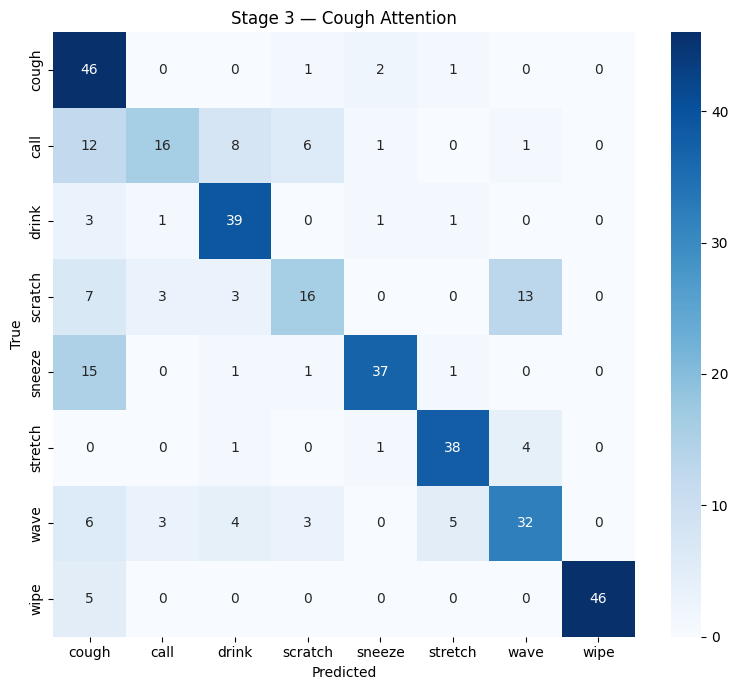


=== + Savitzky-Golay (window=7) ===
              precision    recall  f1-score   support

       cough       0.53      0.84      0.65        50
        call       0.71      0.39      0.50        44
       drink       0.66      0.93      0.77        45
     scratch       0.57      0.31      0.40        42
      sneeze       0.73      0.64      0.68        55
     stretch       0.73      0.91      0.81        44
        wave       0.71      0.55      0.62        53
        wipe       1.00      0.96      0.98        51

    accuracy                           0.70       384
   macro avg       0.70      0.69      0.68       384
weighted avg       0.71      0.70      0.68       384



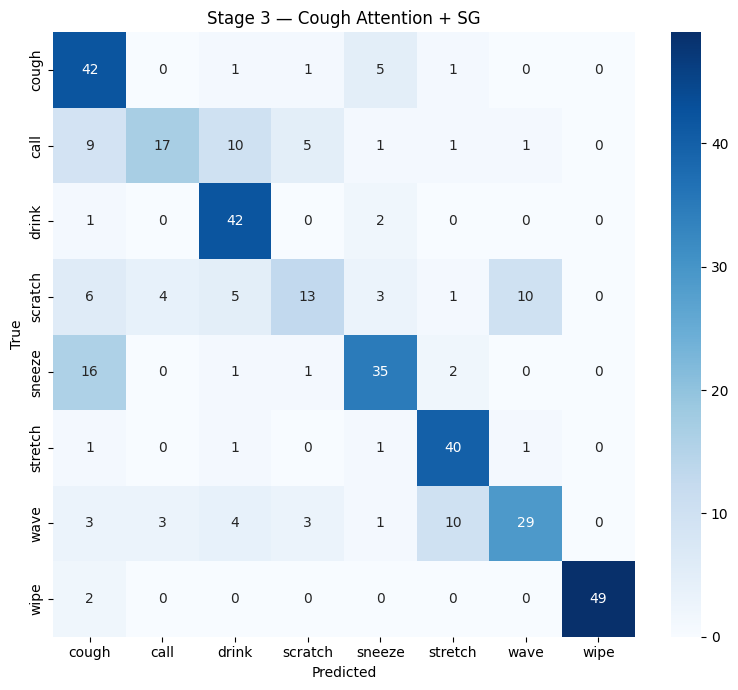

In [25]:
# ── Блок 15: Stage 3 — финальная оценка ──────────────────────────────────
best3 = trainer3.checkpoint_callback.best_model_path
model3_best = STGCNStage2.load_from_checkpoint(best3, cfg=cfg3)

print("=== RAW (no smoothing) ===")
y3, yp3 = run_eval(model3_best, dm3.val_dataloader(), BIISK_CLASSES)
plot_cm(y3, yp3, BIISK_CLASSES, "Stage 3 — Cough Attention")

print("\n=== + Savitzky-Golay (window=7) ===")
y3s, yp3s = run_eval(model3_best, dm3.val_dataloader(), BIISK_CLASSES, smooth=True)
plot_cm(y3s, yp3s, BIISK_CLASSES, "Stage 3 — Cough Attention + SG")

In [28]:
# ── Блок 16: Сравнение стадий ─────────────────────────────────────────────
from sklearn.metrics import f1_score, recall_score

RESP_IDX = [BIISK_CLASSES.index("cough"), BIISK_CLASSES.index("sneeze")]

def resp_recall(y_true, y_pred):
    """Recall по объединённому respiratory классу (cough + sneeze)."""
    y_bin_t = np.isin(y_true, RESP_IDX).astype(int)
    y_bin_p = np.isin(y_pred, RESP_IDX).astype(int)
    return recall_score(y_bin_t, y_bin_p)

rows = [
    ("Stage 2 baseline (no attn)", y_true2, y_pred2),
    ("Stage 3 (spatial+temporal attn)", y3,  yp3),
    ("Stage 3 + SG smoothing",  y3s, yp3s),
]

print(f"{'Модель':<40} {'macro-F1':>10} {'resp-recall':>12}")
print("─" * 65)
for name, yt, yp in rows:
    f1   = f1_score(yt, yp, average="macro")
    rr   = resp_recall(yt, yp)
    print(f"{name:<40} {f1:>10.3f} {rr:>12.3f}")

NameError: name 'y_true2' is not defined

In [26]:
# ── Блок 17: Attention — визуализация суставов ────────────────────────────
import torch.nn.functional as F

JOINT_NAMES = [
    "nose","l_eye","r_eye","l_ear","r_ear",
    "l_sho","r_sho","l_elb","r_elb",
    "l_wri","r_wri","l_hip","r_hip",
    "l_kne","r_kne","l_ank","r_ank"
]

model3_best.eval().cuda()
hooks, attn_weights = [], {}

def hook_fn(name):
    def fn(module, inp, out):
        # SpatialAttention.fc выдаёт (B, V) после softmax
        attn_weights[name] = out.detach().cpu()
    return fn

h = model3_best.head.spatial_attn.fc.register_forward_hook(hook_fn("spatial"))
hooks.append(h)

# Прогоняем один батч кашля
cough_samples = [(x, y) for x, y in dm3.val_ds
                 if y == BIISK_CLASSES.index("cough")][:16]
xb  = torch.stack([s[0] for s in cough_samples]).cuda()
with torch.no_grad(): _ = model3_best(xb)

for h in hooks: h.remove()

# Рисуем
w = attn_weights["spatial"].mean(0).numpy()   # (17,) - среднее по батчу
plt.figure(figsize=(12, 3))
bars = plt.bar(JOINT_NAMES, w, color=["red" if "sho" in j or "wri" in j or j=="nose"
                                       else "steelblue" for j in JOINT_NAMES])
plt.title("Spatial Attention — средние веса суставов (класс: cough)")
plt.xticks(rotation=45, ha="right"); plt.ylabel("Attention weight")
plt.tight_layout(); plt.show()

AttributeError: 'SpatialAttention' object has no attribute 'fc'

# Сохранение финальной модели

In [42]:
# ── Блок 18: Экспорт финальной модели ────────────────────────────────────
FINAL_CKPT = best3
print(f"Финальный чекпоинт: {FINAL_CKPT}")

# Для инференса на CCTV — загрузка одной строкой:
# model = STGCNStage2.load_from_checkpoint(FINAL_CKPT, cfg=cfg3)
# model.eval().cuda()

# Экспорт в TorchScript (опционально)
dummy = torch.randn(1, 2, 64, 17).cuda()
model3_best.eval().cuda()
try:
    traced = torch.jit.trace(model3_best, dummy)
    traced.save("checkpoints/stage3_cough_attn/model_traced.pt")
    print("✅ TorchScript сохранён")
except Exception as e:
    print(f"⚠ TorchScript не удался: {e}")
    print("   Используй load_from_checkpoint для инференса")

Финальный чекпоинт: C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3_cough_attn\stage3_cough_attn-epoch=26-val/f1=0.369.ckpt
⚠ TorchScript не удался: STGCNStage2 is not attached to a `Trainer`.
   Используй load_from_checkpoint для инференса


# Проверка attention


In [44]:
# Ячейка диагностики — запусти перед обучением Stage 3

import torch
ckpt = torch.load(BACKBONE_S2, map_location="cpu")

print("Ключи верхнего уровня:", list(ckpt.keys()))
# Ожидаем: ['epoch', 'global_step', 'state_dict', 'hyper_parameters', ...]

sd = ckpt["state_dict"]
backbone_keys = [k for k in sd if k.startswith("backbone.")]
head_keys     = [k for k in sd if k.startswith("head.")]
bn_keys       = [k for k in sd if k.startswith("data_bn.")]

print(f"backbone ключей : {len(backbone_keys)}")   # ожидаем ~100+
print(f"head ключей     : {len(head_keys)}")        # ожидаем ~10
print(f"data_bn ключей  : {len(bn_keys)}")          # ожидаем 4

# Проверяем что backbone из Stage 2 НЕ случайный
# (веса не должны быть near-zero или идентичны инициализации)
w_first = sd["backbone.0.gcn.weight"].float()
w_last  = sd["backbone.6.gcn.weight"].float()
print(f"\nbackbone.0 mean/std: {w_first.mean():.4f} / {w_first.std():.4f}")
print(f"backbone.6 mean/std: {w_last.mean():.4f} / {w_last.std():.4f}")
# Если std ≈ 0.01–0.02 — это случайная инициализация (backbone не загрузился!)
# Если std > 0.05 — backbone обученный ✅

# Проверяем что модель Stage 3 загрузила backbone
model3 = STGCNStage2(cfg3)
w_model = model3.backbone[0].gcn.weight.float()
print(f"\nmodel3.backbone.0 mean/std: {w_model.mean():.4f} / {w_model.std():.4f}")
# Должно совпадать со значениями из checkpoint выше ✅

Ключи верхнего уровня: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters']
backbone ключей : 126
head ключей     : 4
data_bn ключей  : 5

backbone.0 mean/std: 0.0326 / 0.4750
backbone.6 mean/std: -0.0093 / 0.0742
✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val/f1=0.821.ckpt
   head (переинициализирован): 8
❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются
   Параметров: 1,456,666 / 1,906,718 (76.4%)

model3.backbone.0 mean/std: 0.0326 / 0.4750


In [30]:
# Критичные поля для Stage 3 — проверь каждое
checks = {
    "backbone_ckpt":        cfg3.model.backbone_ckpt,        # путь к Stage 2 ckpt
    "freeze_strategy":      cfg3.model.freeze_strategy,       # должен быть "freeze_early" или "full"
    "use_spatial_attn":     cfg3.model.use_spatial_attn,      # True
    "use_temporal_attn":    cfg3.model.use_temporal_attn,     # True
    "lr":                   cfg3.train.lr,                     # 1e-4 (не 3e-4!)
    "lr_backbone":          cfg3.train.lr_backbone,            # 1e-5
    "dropout":              cfg3.model.dropout,                # 0.3–0.4
    "class_weights":        cfg3.train.class_weights,          # [3.0, 1.0, ...]
    "num_classes":          cfg3.model.num_classes,            # 8
    "num_joints":           cfg3.data.num_joints,              # 17
    "max_epochs":           cfg3.train.max_epochs,             # 40
}
for k, v in checks.items():
    print(f"  {k:25s}: {v}")

# Особо важно: backbone_ckpt должен указывать на Stage 2 файл, а не Stage 1 или пустую строку
import os
ckpt_path = cfg3.model.backbone_ckpt
print(f"\nbackbone_ckpt существует: {os.path.exists(ckpt_path)}")
print(f"Размер файла: {os.path.getsize(ckpt_path) / 1e6:.1f} MB")

  backbone_ckpt            : C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3_cough_attn\phase1-epoch=07.ckpt
  freeze_strategy          : freeze_early
  use_spatial_attn         : True
  use_temporal_attn        : True
  lr                       : 0.0001
  lr_backbone              : 1e-05
  dropout                  : 0.4
  class_weights            : [3.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0]
  num_classes              : 8
  num_joints               : 17
  max_epochs               : 40

backbone_ckpt существует: True
Размер файла: 8.9 MB


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd

# Корень BIISK
root = Path(r"C:\diplommaga\dataset\handlerntu\fine_tuning\data_stage2\biisk_skeletons")

rows = []
for cls_dir in sorted(d for d in root.iterdir() if d.is_dir()):
    cls = cls_dir.name
    lengths = []
    for p in cls_dir.glob("*.npz"):
        data = np.load(p)
        seq  = data["skeleton"]      # (T, 17, 3)
        lengths.append(seq.shape[0]) # T
    if lengths:
        lengths = np.array(lengths)
        rows.append({
            "class":   cls,
            "count":   len(lengths),
            "min_T":   int(lengths.min()),
            "max_T":   int(lengths.max()),
            "mean_T":  float(lengths.mean()),
        })

df = pd.DataFrame(rows).sort_values("class")
display(df)

print("\nГлобальная статистика по всем классам:")
all_T = np.concatenate([
    np.repeat(row["mean_T"], row["count"])
    for row in rows
])
print(f"min_T = {min(r['min_T'] for r in rows):.0f}")
print(f"max_T = {max(r['max_T'] for r in rows):.0f}")
print(f"mean_T≈ {all_T.mean():.1f}")

,class,count,min_T,max_T,mean_T
0,call,240,46,121,77.583333
1,cough,240,41,181,68.125000
2,drink,240,36,106,70.541667
3,scratch,240,36,101,64.041667
4,sneeze,240,31,96,58.208333
5,stretch,240,41,96,66.500000
6,wave,240,31,91,58.291667
7,wipe,240,56,111,85.958333



Глобальная статистика по всем классам:
min_T = 31
max_T = 181
mean_T≈ 68.7


# STAGE 3_V2

In [28]:
BACKBONE_S2 = r"C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val\f1=0.821.ckpt"


In [33]:
cfg3 = OmegaConf.create({
    "data": {
        "skeleton_root": r"c:\diplommaga\dataset\handlerntu\fine_tuning\data_stage2\biisk_skeletons",
        "classes":        BIISK_CLASSES,
        "num_frames":     64,
        "num_joints":     17,
        "conf_thresh":    0.0,
        "cache":          True,
    },
    "augmentation": {
        "enabled":        True,
        "mirror_prob":    0.5,
        "rotate2d_prob":  0.4,
        "rotate2d_range": 15.0,
        "noise_std":      0.02,
        "time_crop_prob": 0.5,
        "time_crop_frac": 0.20,
    },
    "model": {
        "in_channels":      2,
        "hidden_dim":       256,
        "num_classes":      8,
        "dropout":          0.4,
        "backbone_ckpt":    BACKBONE_S2,
        "freeze_strategy":  "freeze_all",   # Фаза 1
        "use_spatial_attn": True,
        "use_temporal_attn":True,
    },
    "train": {
        "batch_size":   32,
        "num_workers":  4,
        "max_epochs":   10,            # Фаза 1
        "lr":           5e-4,
        "lr_backbone":  0.0,
        "weight_decay": 1e-4,
        "val_split":    0.2,
        "seed":         42,
        "ckpt_dir":     r"c:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3",
        "log_dir":      r"c:\diplommaga\dataset\handlerntu\fine_tuning\logs_stage3",
        "class_weights": [3.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0],
        # cough↑ sneeze↑ остальные нейтральны
    },
})

In [30]:
dm3 = BiiskDataModule(cfg3)
dm3.setup("fit")
xb, yb = next(iter(dm3.train_dataloader()))
print(f"Batch: {xb.shape} | Labels: {yb.shape}")
print(f"Train: {len(dm3.train_ds)} | Val: {len(dm3.val_ds)}")


Предзагрузка 1920 файлов в RAM...
✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Предзагрузка 1920 файлов в RAM...
✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Train: 1536 | Val: 384
Batch: torch.Size([32, 2, 64, 17]) | Labels: torch.Size([32])
Train: 1536 | Val: 384


In [34]:
def make_trainer_stage3(cfg, name):
    return pl.Trainer(
        max_epochs        = cfg.train.max_epochs,
        accelerator       = "gpu",
        devices           = 1,
        log_every_n_steps = 5,
        logger            = TensorBoardLogger(cfg.train.log_dir, name=name),
        callbacks         = [
            ModelCheckpoint(
                dirpath   = cfg.train.ckpt_dir,
                filename  = name + "-{epoch:02d}-{val/f1:.3f}",
                monitor   = "val/f1",
                mode      = "max",
                save_top_k= 2,
                save_last = True,
            ),
            EarlyStopping(
                monitor   = "val/f1",
                mode      = "max",
                patience  = 6,
                verbose   = True,
            ),
        ],
    )

print("=" * 60)
print("ФАЗА 1: прогрев attention (freeze_all, lr=5e-4, 10 эпох)")
print("=" * 60)

model3_p1   = STGCNStage2(cfg3)
trainer3_p1 = make_trainer_stage3(cfg3, name="stage3_phase1")
trainer3_p1.fit(model3_p1, datamodule=dm3)

best_p1 = trainer3_p1.checkpoint_callback.best_model_path
print(f"\n✅ Фаза 1 завершена. Лучший ckpt: {best_p1}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


ФАЗА 1: прогрев attention (freeze_all, lr=5e-4, 10 эпох)
✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_biisk\stage2_biisk-epoch=38-val\f1=0.821.ckpt
   head (переинициализирован): 8
❄️  freeze_all: только head
   Параметров: 68,362 / 1,832,974 (3.7%)
Предзагрузка 1920 файлов в RAM...
✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Предзагрузка 1920 файлов в RAM...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | STGCNHead          | 68.4 K | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | val_f1    | MulticlassF1Score  | 0      | train | 0    
-----------------------------------------------------------------
68.4 K    Trainable params
1.8 M     Non-trainable params
1.8 M     Total params
7.332     Total estimated model params size (MB)
96        Modules in train mode
0         Modules in eval mode
0         Total Flops


✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Train: 1536 | Val: 384
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


...

Epoch 5: 100%|██████████| 48/48 [00:40<00:00,  1.19it/s, v_num=1, train/loss_step=1.120, train/acc_step=0.469, train/f1_step=0.478, val/loss=0.832, val/acc=0.674, val/f1=0.659, train/loss_epoch=0.800, train/acc_epoch=0.705, train/f1_epoch=0.697]

Metric val/f1 improved by 0.022 >= min_delta = 0.0. New best score: 0.659


Epoch 9: 100%|██████████| 48/48 [00:41<00:00,  1.14it/s, v_num=1, train/loss_step=0.805, train/acc_step=0.625, train/f1_step=0.606, val/loss=0.810, val/acc=0.672, val/f1=0.652, train/loss_epoch=0.758, train/acc_epoch=0.715, train/f1_epoch=0.711]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 48/48 [00:41<00:00,  1.14it/s, v_num=1, train/loss_step=0.805, train/acc_step=0.625, train/f1_step=0.606, val/loss=0.810, val/acc=0.672, val/f1=0.652, train/loss_epoch=0.758, train/acc_epoch=0.715, train/f1_epoch=0.711]

✅ Фаза 1 завершена. Лучший ckpt: C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3\stage3_phase1-epoch=05-val/f1=0.659.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


ФАЗА 2: fine-tune (freeze_early, lr=1e-4, 40 эпох)
✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3\stage3_phase1-epoch=05-val/f1=0.659.ckpt
   head (переинициализирован): 8
❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются
   Параметров: 1,382,922 / 1,832,974 (75.4%)
Предзагрузка 1920 файлов в RAM...
✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Предзагрузка 1920 файлов в RAM...


c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | STGCNHead          | 68.4 K | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | val_f1    | MulticlassF1Score  | 0      | train | 0    
-----------------------------------------------------------------
1.4 M     Trainable params
450 K     Non-trainable params
1.8 M     Total params
7.332     Total estimated model params size (M

✅ Кэш заполнен
BiiskDataset: 1920 сэмплов | 8 классов | cache=True
Train: 1536 | Val: 384
Epoch 0: 100%|██████████| 48/48 [00:22<00:00,  2.15it/s, v_num=0, train/loss_step=2.040, train/acc_step=0.125, train/f1_step=0.0659, val/loss=2.000, val/acc=0.154, val/f1=0.0732, train/loss_epoch=2.060, train/acc_epoch=0.126, train/f1_epoch=0.0473]

Metric val/f1 improved. New best score: 0.073


...

Epoch 30: 100%|██████████| 48/48 [00:40<00:00,  1.17it/s, v_num=0, train/loss_step=0.683, train/acc_step=0.719, train/f1_step=0.651, val/loss=0.830, val/acc=0.669, val/f1=0.619, train/loss_epoch=0.791, train/acc_epoch=0.698, train/f1_epoch=0.683]

Metric val/f1 improved by 0.004 >= min_delta = 0.0. New best score: 0.619


Epoch 36: 100%|██████████| 48/48 [00:41<00:00,  1.16it/s, v_num=0, train/loss_step=0.915, train/acc_step=0.594, train/f1_step=0.598, val/loss=0.833, val/acc=0.667, val/f1=0.616, train/loss_epoch=0.768, train/acc_epoch=0.693, train/f1_epoch=0.676]

Monitored metric val/f1 did not improve in the last 6 records. Best score: 0.619. Signaling Trainer to stop.


Epoch 36: 100%|██████████| 48/48 [00:41<00:00,  1.16it/s, v_num=0, train/loss_step=0.915, train/acc_step=0.594, train/f1_step=0.598, val/loss=0.833, val/acc=0.667, val/f1=0.616, train/loss_epoch=0.768, train/acc_epoch=0.693, train/f1_epoch=0.676]

✅ Фаза 2 завершена. Лучший ckpt: C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3\stage3_phase2-epoch=30-val/f1=0.619.ckpt
✅ Backbone загружен из C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage3\stage3_phase1-epoch=05-val/f1=0.659.ckpt
   head (переинициализирован): 8
❄️  freeze_early: блоки 0-4 заморожены, 5-6 + head обучаются
   Параметров: 1,382,922 / 1,832,974 (75.4%)
              precision    recall  f1-score   support

       cough       0.62      0.78      0.69        50
        call       0.80      0.09      0.16        44
       drink       0.69      0.96      0.80        45
     scratch       0.35      0.19      0.25        42
      sneeze       0.86      0.76      0.81        55
     stretch       0.6

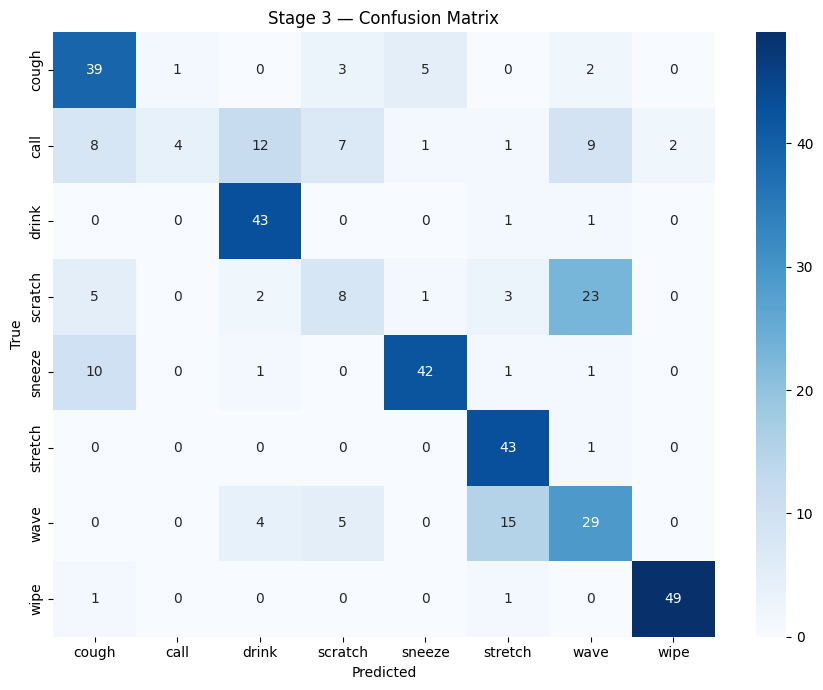


Бинарная задача resp=(cough+sneeze) vs background:
  precision = 0.857
  recall    = 0.914   ← ключевая метрика
  F1        = 0.885


In [35]:
print("=" * 60)
print("ФАЗА 2: fine-tune (freeze_early, lr=1e-4, 40 эпох)")
print("=" * 60)

cfg3.model.backbone_ckpt   = best_p1         # берём прогретую модель из фазы 1
cfg3.model.freeze_strategy = "freeze_early"  # размораживаем блоки 5-6
cfg3.train.max_epochs      = 40
cfg3.train.lr              = 1e-4
cfg3.train.lr_backbone     = 1e-5

model3_p2   = STGCNStage2(cfg3)
trainer3_p2 = make_trainer_stage3(cfg3, name="stage3_phase2")
trainer3_p2.fit(model3_p2, datamodule=dm3)

best_p2 = trainer3_p2.checkpoint_callback.best_model_path
print(f"\n✅ Фаза 2 завершена. Лучший ckpt: {best_p2}")


# ── Ячейка 9: Оценка финальной модели ──────────────────────────────────────
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy.signal import savgol_filter

def run_eval_biisk(model, loader, classes, device="cuda", smooth=False):
    model.eval().to(device)
    all_y, all_p = [], []
    with torch.no_grad():
        for xb, yb in loader:
            if smooth:
                arr = savgol_filter(xb.numpy(), window_length=7,
                                    polyorder=2, axis=2)
                xb  = torch.tensor(arr, dtype=torch.float32)
            out  = model(xb.to(device))
            all_y.append(yb.numpy())
            all_p.append(out.argmax(1).cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    print(classification_report(y_true, y_pred, target_names=classes))
    return y_true, y_pred

model3_final = STGCNStage2.load_from_checkpoint(best_p2, cfg=cfg3)
y_true3, y_pred3 = run_eval_biisk(
    model3_final, dm3.val_dataloader(), BIISK_CLASSES)

# Confusion matrix
cm = confusion_matrix(y_true3, y_pred3)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=BIISK_CLASSES, yticklabels=BIISK_CLASSES)
plt.title("Stage 3 — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

# Бинарная resp оценка
resp_classes = {"cough", "sneeze"}
resp_idx     = {i for i, c in enumerate(BIISK_CLASSES) if c in resp_classes}
y_bin_true   = np.isin(y_true3, list(resp_idx)).astype(int)
y_bin_pred   = np.isin(y_pred3, list(resp_idx)).astype(int)
from sklearn.metrics import precision_recall_fscore_support
p, r, f, _ = precision_recall_fscore_support(
                 y_bin_true, y_bin_pred, average="binary")
print(f"\nБинарная задача resp=(cough+sneeze) vs background:")
print(f"  precision = {p:.3f}")
print(f"  recall    = {r:.3f}   ← ключевая метрика")
print(f"  F1        = {f:.3f}")

## Визуализация attention

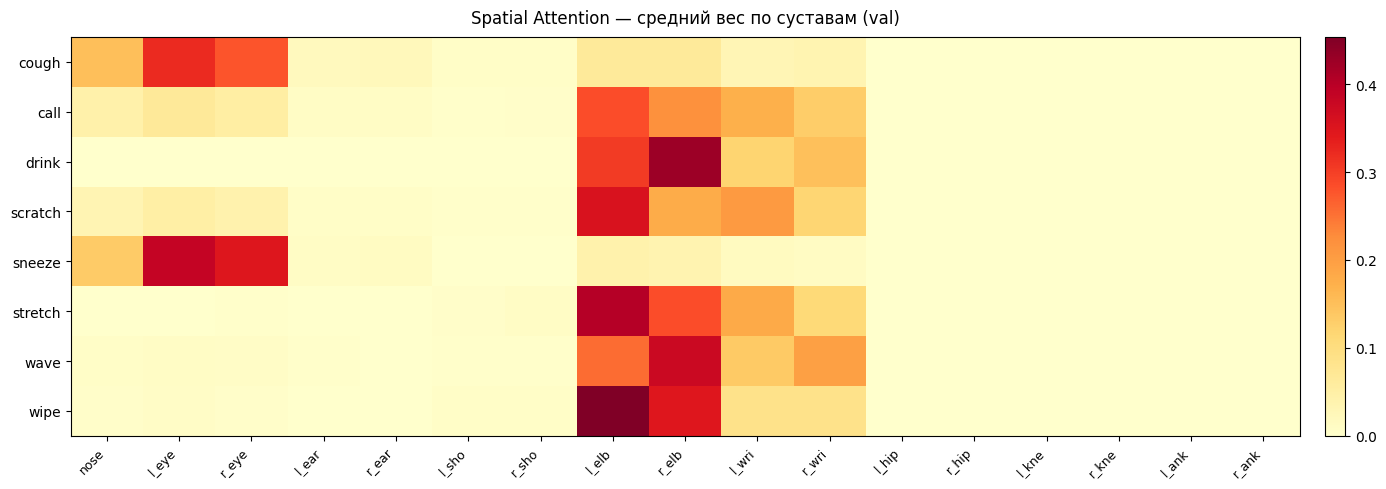

✅ Сохранено: stage3_spatial_attention_heatmap.png


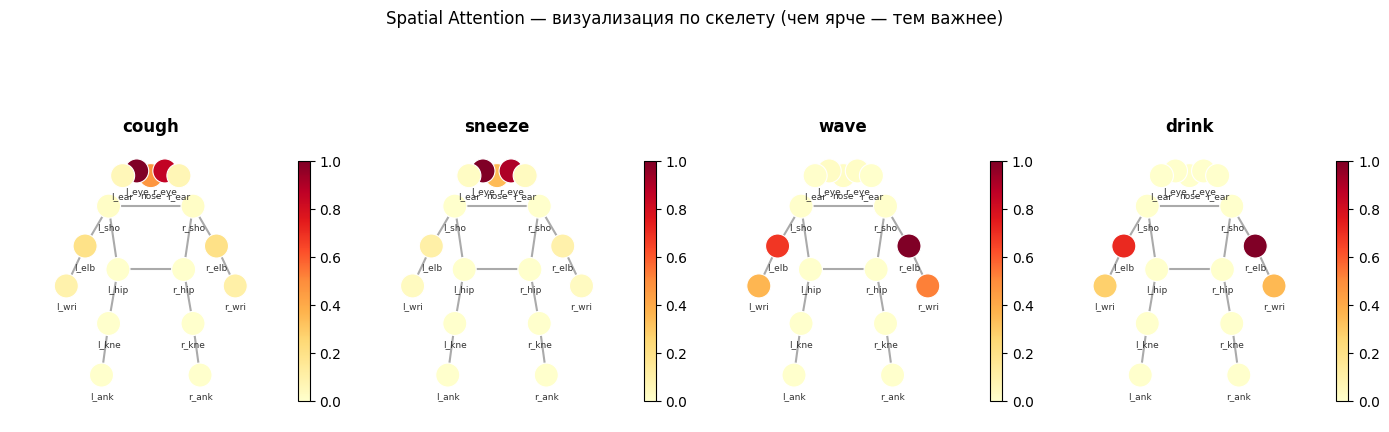

✅ Сохранено: stage3_skeleton_attention.png


In [36]:
"""
Собираем средние веса spatial attention по всем val-примерам,
отдельно для каждого класса → тепловая карта (класс × сустав).
"""
COCO17_NAMES = [
    "nose",       # 0
    "l_eye",      # 1
    "r_eye",      # 2
    "l_ear",      # 3
    "r_ear",      # 4
    "l_sho",      # 5
    "r_sho",      # 6
    "l_elb",      # 7
    "r_elb",      # 8
    "l_wri",      # 9
    "r_wri",      # 10
    "l_hip",      # 11
    "r_hip",      # 12
    "l_kne",      # 13
    "r_kne",      # 14
    "l_ank",      # 15
    "r_ank",      # 16
]

# Хук для перехвата весов
captured = {"w": []}
def _hook(module, inp, out):
    # out = (B, V) после softmax
    captured["w"].append(out.detach().cpu())

h = model3_final.head.spatial_attn.softmax.register_forward_hook(
    lambda m, i, o: captured["w"].append(o.detach().cpu())
)

model3_final.eval()
all_cls = []
with torch.no_grad():
    for xb, yb in dm3.val_dataloader():
        _ = model3_final(xb.cuda())
        all_cls.append(yb.numpy())
h.remove()

attn_weights = torch.cat(captured["w"], dim=0).numpy()   # (N, 17)
all_classes  = np.concatenate(all_cls)                    # (N,)

# Средний вес по классу
n_cls    = len(BIISK_CLASSES)
mean_attn = np.zeros((n_cls, 17))
for c in range(n_cls):
    mask = all_classes == c
    if mask.sum() > 0:
        mean_attn[c] = attn_weights[mask].mean(axis=0)

# ── Heatmap: классы × суставы ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(mean_attn, aspect="auto", cmap="YlOrRd",
               vmin=0, vmax=mean_attn.max())
ax.set_xticks(range(17))
ax.set_xticklabels(COCO17_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n_cls))
ax.set_yticklabels(BIISK_CLASSES, fontsize=10)
ax.set_title("Spatial Attention — средний вес по суставам (val)", pad=10)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
plt.tight_layout()
plt.savefig("stage3_spatial_attention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Сохранено: stage3_spatial_attention_heatmap.png")


# ── Ячейка 4: Spatial Attention — отдельно для cough ───────────────────────
"""
Скелет с весами в виде цветных точек: чем ярче — тем важнее сустав.
"""
SKELETON_EDGES = [
    (0,1),(0,2),(1,3),(2,4),         # голова
    (5,6),(5,7),(7,9),(6,8),(8,10),  # руки
    (5,11),(6,12),(11,12),           # торс
    (11,13),(13,15),(12,14),(14,16), # ноги
]

# Позиция суставов COCO-17 для схематичного скелета (x, y — нормировано)
COCO17_XY = np.array([
    [0.50, 0.95],  # 0  nose
    [0.44, 0.97],  # 1  l_eye
    [0.56, 0.97],  # 2  r_eye
    [0.38, 0.95],  # 3  l_ear
    [0.62, 0.95],  # 4  r_ear
    [0.32, 0.82],  # 5  l_sho
    [0.68, 0.82],  # 6  r_sho
    [0.22, 0.65],  # 7  l_elb
    [0.78, 0.65],  # 8  r_elb
    [0.14, 0.48],  # 9  l_wri
    [0.86, 0.48],  # 10 r_wri
    [0.36, 0.55],  # 11 l_hip
    [0.64, 0.55],  # 12 r_hip
    [0.32, 0.32],  # 13 l_kne
    [0.68, 0.32],  # 14 r_kne
    [0.29, 0.10],  # 15 l_ank
    [0.71, 0.10],  # 16 r_ank
])

TARGET_CLASSES = ["cough", "sneeze", "wave", "drink"]
fig, axes = plt.subplots(1, len(TARGET_CLASSES), figsize=(14, 5))

for ax, cls_name in zip(axes, TARGET_CLASSES):
    cls_idx = BIISK_CLASSES.index(cls_name)
    weights = mean_attn[cls_idx]                   # (17,)
    w_norm  = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)

    # рёбра скелета
    for i, j in SKELETON_EDGES:
        x = [COCO17_XY[i, 0], COCO17_XY[j, 0]]
        y = [COCO17_XY[i, 1], COCO17_XY[j, 1]]
        ax.plot(x, y, color="#aaaaaa", lw=1.5, zorder=1)

    # суставы с весами
    sc = ax.scatter(
        COCO17_XY[:, 0], COCO17_XY[:, 1],
        c=w_norm, cmap="YlOrRd",
        s=300, zorder=2,
        edgecolors="white", linewidths=0.8,
        vmin=0, vmax=1,
    )
    # подписи суставов
    for v, (x, y) in enumerate(COCO17_XY):
        ax.text(x, y - 0.07, COCO17_NAMES[v],
                ha="center", va="top", fontsize=6.5, color="#333333")

    ax.set_title(cls_name, fontsize=12, fontweight="bold")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)

plt.suptitle("Spatial Attention — визуализация по скелету (чем ярче — тем важнее)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("stage3_skeleton_attention.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Сохранено: stage3_skeleton_attention.png")